In [1]:
# Cell 1: Setup environment for toxic comment classification

!pip -q install datasets transformers accelerate evaluate

import warnings
warnings.filterwarnings("ignore")

import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from datasets import load_dataset
from transformers import set_seed


TOXIC_SEED = 777

random.seed(TOXIC_SEED)
np.random.seed(TOXIC_SEED)
torch.manual_seed(TOXIC_SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(TOXIC_SEED)

set_seed(TOXIC_SEED)


device = "cuda" if torch.cuda.is_available() else "cpu"

print("Toxic comment classification environment ready.")
print("PyTorch:", torch.__version__)
print("Device:", device)
print("Seed:", TOXIC_SEED)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.9 MB/s eta 0:00:00
Toxic comment classification environment ready.
PyTorch: 2.11.0+cu128
Device: cuda
Seed: 777


In [3]:
# Cell 2: Load toxic comment dataset (Parquet version)

toxic_data = load_dataset(
    "mteb/toxic_conversations_50k"
)

print(toxic_data)

print("\nAvailable splits:")
for split_name, split_data in toxic_data.items():
    print(f"{split_name}: {len(split_data)} rows")

print("\nFirst example:")
print(toxic_data["train"][0])

print("\nColumns:")
print(toxic_data["train"].column_names)

README.md:   0%|          | 0.00/6.45k [00:00<?, ?B/s]

train.jsonl: reconstructing file:   0%|          |  0.00B / 17.7MB            

train.jsonl: downloading bytes:           |  0.00B            

test.jsonl: reconstructing file:   0%|          |  0.00B / 17.5MB            

test.jsonl: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/50000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'label_text'],
        num_rows: 50000
    })
    test: Dataset({
        features: ['text', 'label', 'label_text'],
        num_rows: 50000
    })
})

Available splits:
train: 50000 rows
test: 50000 rows

First example:
{'text': 'theres not enough going on around here for air service none want to waste there time on this town', 'label': 0, 'label_text': 'not toxic'}

Columns:
['text', 'label', 'label_text']


In [4]:
# Cell 3: Explore toxic comment dataset

toxic_df = toxic_data["train"].to_pandas()

print("Dataset Shape:", toxic_df.shape)

print("\nColumns:")
print(toxic_df.columns.tolist())

print("\nMissing Values:")
print(toxic_df.isnull().sum())

print("\nData Sample:")
display(
    toxic_df.head(10)
)

Dataset Shape: (50000, 3)

Columns:
['text', 'label', 'label_text']

Missing Values:
text          0
label         0
label_text    0
dtype: int64

Data Sample:


,text,label,label_text
0,theres not enough going on around here for air...,0,not toxic
1,How about ZERO,0,not toxic
2,Her name is still floating? Might I suggest f...,0,not toxic
3,Stop by So Cold at MFNW/Project Pabst! It'll m...,0,not toxic
4,"Nobody awake on the bridge, no lookouts ,,no r...",0,not toxic
5,Pessimist's might say that we the US will have...,0,not toxic
6,I'm sure Hawaiian can put Southwest out of bus...,0,not toxic
7,"States don't grow economies, cities grow econo...",0,not toxic
8,What makes Magnitsky so special? Countless tho...,0,not toxic
9,"The Mayor said we need ""more skin in the game""...",0,not toxic


In [5]:
# Cell 4: Identify input text and label columns

print("Dataset columns:")
print(toxic_df.columns.tolist())

# Find possible text column
text_candidates = [
    col for col in toxic_df.columns
    if "text" in col.lower()
    or "comment" in col.lower()
    or "content" in col.lower()
]

print("\nPossible text columns:")
print(text_candidates)

# Display unique values for possible label columns
for col in toxic_df.columns:
    if col not in text_candidates:
        print("\nColumn:", col)
        print(toxic_df[col].value_counts().head())

Dataset columns:
['text', 'label', 'label_text']

Possible text columns:
['text', 'label_text']

Column: label
label
0    46035
1     3965
Name: count, dtype: int64


In [6]:
# Cell 5: Prepare toxic comment data

# Keep only required columns
toxic_df = toxic_df[["text", "label"]].copy()

# Convert labels into readable categories
toxic_labels = {
    0: "Non-toxic",
    1: "Toxic"
}

toxic_df["category"] = toxic_df["label"].map(toxic_labels)

print("Dataset Shape:", toxic_df.shape)

print("\nClass Distribution:")
print(toxic_df["category"].value_counts())

print("\nSample Comments:")
display(
    toxic_df.head(10)
)

Dataset Shape: (50000, 3)

Class Distribution:
category
Non-toxic    46035
Toxic         3965
Name: count, dtype: int64

Sample Comments:


,text,label,category
0,theres not enough going on around here for air...,0,Non-toxic
1,How about ZERO,0,Non-toxic
2,Her name is still floating? Might I suggest f...,0,Non-toxic
3,Stop by So Cold at MFNW/Project Pabst! It'll m...,0,Non-toxic
4,"Nobody awake on the bridge, no lookouts ,,no r...",0,Non-toxic
5,Pessimist's might say that we the US will have...,0,Non-toxic
6,I'm sure Hawaiian can put Southwest out of bus...,0,Non-toxic
7,"States don't grow economies, cities grow econo...",0,Non-toxic
8,What makes Magnitsky so special? Countless tho...,0,Non-toxic
9,"The Mayor said we need ""more skin in the game""...",0,Non-toxic


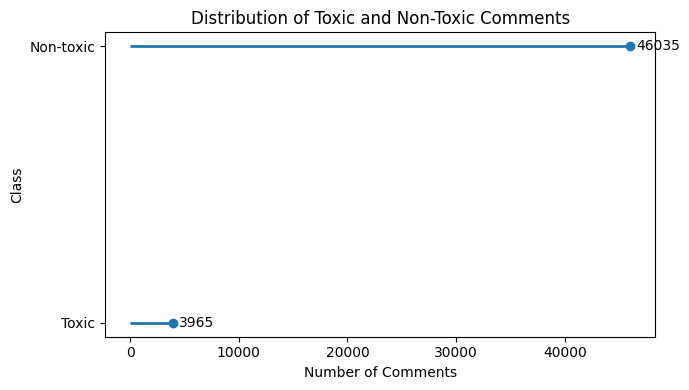

In [7]:
# Cell 6: Visualise toxicity class distribution

class_distribution = (
    toxic_df["category"]
    .value_counts()
    .sort_values()
)

plt.figure(figsize=(7, 4))

plt.hlines(
    y=class_distribution.index,
    xmin=0,
    xmax=class_distribution.values,
    linewidth=2
)

plt.plot(
    class_distribution.values,
    class_distribution.index,
    "o"
)

for index, value in enumerate(class_distribution.values):
    plt.text(
        value + 500,
        index,
        str(value),
        va="center"
    )

plt.title("Distribution of Toxic and Non-Toxic Comments")
plt.xlabel("Number of Comments")
plt.ylabel("Class")

plt.tight_layout()
plt.show()

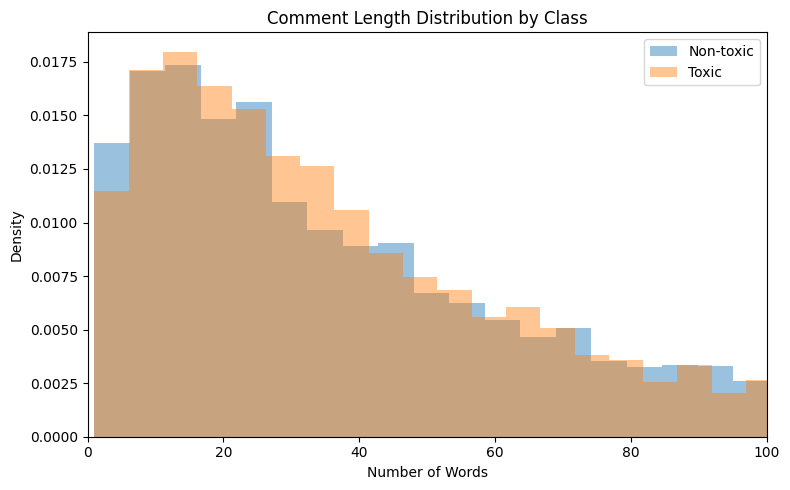

Comment Length Statistics:


,count,mean,std,min,25%,50%,75%,max
category,,,,,,,,
Non-toxic,46035.0,51.783795,46.570111,1.0,16.0,36.0,72.0,210.0
Toxic,3965.0,49.032535,43.311857,1.0,18.0,34.0,66.0,203.0


In [9]:
# Cell 7: Analyse comment length distribution

# Calculate word count
toxic_df["comment_length"] = (
    toxic_df["text"]
    .str.split()
    .str.len()
)

plt.figure(figsize=(8, 5))

for category in toxic_df["category"].unique():

    values = toxic_df.loc[
        toxic_df["category"] == category,
        "comment_length"
    ]

    plt.hist(
        values,
        bins=40,
        alpha=0.45,
        density=True,
        label=category
    )

plt.title("Comment Length Distribution by Class")
plt.xlabel("Number of Words")
plt.ylabel("Density")

plt.legend()

plt.xlim(0, 100)

plt.tight_layout()
plt.show()


print("Comment Length Statistics:")
display(
    toxic_df.groupby("category")["comment_length"].describe()
)

In [10]:
# Cell 8: Split toxic comment dataset

from sklearn.model_selection import train_test_split

# First create train and test split
train_df, test_df = train_test_split(
    toxic_df,
    test_size=0.15,
    stratify=toxic_df["label"],
    random_state=TOXIC_SEED
)

# Create validation split from training data
train_df, validation_df = train_test_split(
    train_df,
    test_size=0.15,
    stratify=train_df["label"],
    random_state=TOXIC_SEED
)

# Reset indexes
train_df = train_df.reset_index(drop=True)
validation_df = validation_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Training Set:", train_df.shape)
print("Validation Set:", validation_df.shape)
print("Test Set:", test_df.shape)

print("\nTraining distribution:")
print(train_df["label"].value_counts())

print("\nValidation distribution:")
print(validation_df["label"].value_counts())

print("\nTest distribution:")
print(test_df["label"].value_counts())

Training Set: (36125, 4)
Validation Set: (6375, 4)
Test Set: (7500, 4)

Training distribution:
label
0    33261
1     2864
Name: count, dtype: int64

Validation distribution:
label
0    5869
1     506
Name: count, dtype: int64

Test distribution:
label
0    6905
1     595
Name: count, dtype: int64


In [11]:
# Cell 9: Create Hugging Face DatasetDict

from datasets import Dataset, DatasetDict

toxic_dataset = DatasetDict({

    "train": Dataset.from_pandas(
        train_df[["text", "label"]],
        preserve_index=False
    ),

    "validation": Dataset.from_pandas(
        validation_df[["text", "label"]],
        preserve_index=False
    ),

    "test": Dataset.from_pandas(
        test_df[["text", "label"]],
        preserve_index=False
    )
})

print(toxic_dataset)

print("\nExample training record:")
print(toxic_dataset["train"][0])

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 36125
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 6375
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7500
    })
})

Example training record:
{'text': "What questionable deals?\nYou Liberals must be crapping your pants about now.\n\nThat twit you have won;t last another election.\nOnce we audit that slush fund Trudeau Foundation I'm sure Khan will have made a few 100 million in donations then all will become clear.", 'label': 0}


In [12]:
# Cell 10: Train TF-IDF Logistic Regression toxicity classifier

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression


toxic_vectorizer = TfidfVectorizer(
    lowercase=True,
    ngram_range=(1, 2),
    max_features=20000,
    min_df=2,
    sublinear_tf=True
)


X_train_toxic = toxic_vectorizer.fit_transform(
    train_df["text"]
)

X_validation_toxic = toxic_vectorizer.transform(
    validation_df["text"]
)

X_test_toxic = toxic_vectorizer.transform(
    test_df["text"]
)


toxic_lr = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=TOXIC_SEED
)


toxic_lr.fit(
    X_train_toxic,
    train_df["label"]
)


print("Logistic Regression baseline trained successfully.")
print("Training matrix shape:", X_train_toxic.shape)
print(
    "Vocabulary size:",
    len(toxic_vectorizer.get_feature_names_out())
)

Logistic Regression baseline trained successfully.
Training matrix shape: (36125, 20000)
Vocabulary size: 20000


In [13]:
# Cell 11: Evaluate Logistic Regression toxicity classifier

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)


lr_toxic_predictions = toxic_lr.predict(
    X_test_toxic
)


lr_accuracy = accuracy_score(
    test_df["label"],
    lr_toxic_predictions
)


lr_precision, lr_recall, lr_f1, _ = (
    precision_recall_fscore_support(
        test_df["label"],
        lr_toxic_predictions,
        average="weighted",
        zero_division=0
    )
)


print("Logistic Regression Test Results")

print(f"Accuracy : {lr_accuracy:.4f}")
print(f"Precision: {lr_precision:.4f}")
print(f"Recall   : {lr_recall:.4f}")
print(f"F1-score : {lr_f1:.4f}")


print("\nClassification Report:")

print(
    classification_report(
        test_df["label"],
        lr_toxic_predictions,
        target_names=[
            "Non-toxic",
            "Toxic"
        ],
        zero_division=0
    )
)


print("Confusion Matrix:")

print(
    confusion_matrix(
        test_df["label"],
        lr_toxic_predictions
    )
)

Logistic Regression Test Results
Accuracy : 0.8917
Precision: 0.9192
Recall   : 0.8917
F1-score : 0.9028

Classification Report:
              precision    recall  f1-score   support

   Non-toxic       0.97      0.92      0.94      6905
       Toxic       0.39      0.62      0.47       595

    accuracy                           0.89      7500
   macro avg       0.68      0.77      0.71      7500
weighted avg       0.92      0.89      0.90      7500

Confusion Matrix:
[[6321  584]
 [ 228  367]]


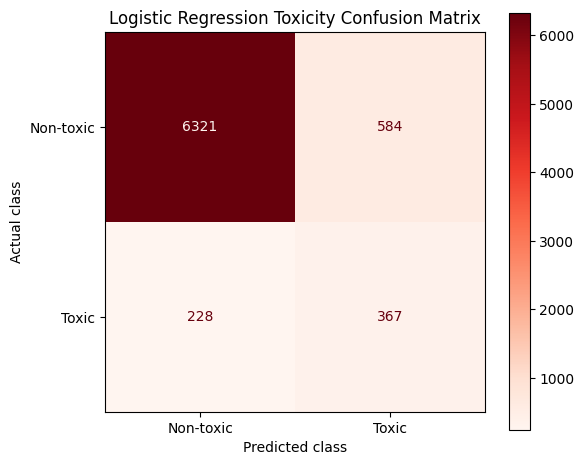

In [14]:
# Cell 12: Plot the baseline confusion matrix

from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(6, 5))

ConfusionMatrixDisplay.from_predictions(
    test_df["label"],
    lr_toxic_predictions,
    display_labels=["Non-toxic", "Toxic"],
    values_format="d",
    cmap="Reds",
    ax=ax
)

ax.set_title("Logistic Regression Toxicity Confusion Matrix")
ax.set_xlabel("Predicted class")
ax.set_ylabel("Actual class")

plt.tight_layout()
plt.show()

In [15]:
# Cell 13: Load DistilBERT tokenizer

from transformers import AutoTokenizer

TOXIC_MODEL = "distilbert-base-uncased"
MAX_TOXIC_LENGTH = 128

toxic_tokenizer = AutoTokenizer.from_pretrained(
    TOXIC_MODEL
)

sample_comment = train_df.loc[0, "text"]

encoded_comment = toxic_tokenizer(
    sample_comment,
    truncation=True,
    max_length=MAX_TOXIC_LENGTH
)

print("DistilBERT tokenizer loaded successfully.")
print("Model:", TOXIC_MODEL)
print("Maximum sequence length:", MAX_TOXIC_LENGTH)

print("\nSample comment:")
print(sample_comment)

print("\nFirst 20 token IDs:")
print(encoded_comment["input_ids"][:20])

print("\nFirst 20 attention-mask values:")
print(encoded_comment["attention_mask"][:20])

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

DistilBERT tokenizer loaded successfully.
Model: distilbert-base-uncased
Maximum sequence length: 128

Sample comment:
What questionable deals?
You Liberals must be crapping your pants about now.

That twit you have won;t last another election.
Once we audit that slush fund Trudeau Foundation I'm sure Khan will have made a few 100 million in donations then all will become clear.

First 20 token IDs:
[101, 2054, 21068, 9144, 1029, 2017, 13350, 2442, 2022, 10231, 4691, 2115, 6471, 2055, 2085, 1012, 2008, 1056, 9148, 2102]

First 20 attention-mask values:
[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


In [16]:
# Cell 14: Tokenize the dataset for DistilBERT

def tokenize_toxic(batch):
    return toxic_tokenizer(
        batch["text"],
        truncation=True,
        max_length=MAX_TOXIC_LENGTH
    )

tokenized_toxic = toxic_dataset.map(
    tokenize_toxic,
    batched=True,
    remove_columns=["text"]
)

print(tokenized_toxic)

example = tokenized_toxic["train"][0]

print("\nExample tokenized comment")
print("Label:", example["label"])
print("First 15 input IDs:", example["input_ids"][:15])
print("First 15 attention-mask values:", example["attention_mask"][:15])

Map:   0%|          | 0/36125 [00:00<?, ? examples/s]

Map:   0%|          | 0/6375 [00:00<?, ? examples/s]

Map:   0%|          | 0/7500 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 36125
    })
    validation: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 6375
    })
    test: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 7500
    })
})

Example tokenized comment
Label: 0
First 15 input IDs: [101, 2054, 21068, 9144, 1029, 2017, 13350, 2442, 2022, 10231, 4691, 2115, 6471, 2055, 2085]
First 15 attention-mask values: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


In [17]:
# Cell 15: Load DistilBERT with a binary classification head

from transformers import AutoModelForSequenceClassification

NUM_TOXIC_CLASSES = 2

toxic_model = AutoModelForSequenceClassification.from_pretrained(
    TOXIC_MODEL,
    num_labels=NUM_TOXIC_CLASSES
)

print("DistilBERT model loaded successfully.")
print("Model:", TOXIC_MODEL)
print("Number of output classes:", toxic_model.config.num_labels)

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBERT model loaded successfully.
Model: distilbert-base-uncased
Number of output classes: 2


In [18]:
# Cell 16: Define evaluation metrics

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support
)

def compute_toxic_metrics(eval_pred):

    logits, labels = eval_pred

    predictions = np.argmax(
        logits,
        axis=1
    )

    precision, recall, f1, _ = (
        precision_recall_fscore_support(
            labels,
            predictions,
            average="weighted",
            zero_division=0
        )
    )

    accuracy = accuracy_score(
        labels,
        predictions
    )

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

print("Evaluation metrics configured successfully.")

Evaluation metrics configured successfully.


In [19]:
# Cell 17: Configure DistilBERT fine-tuning

from transformers import TrainingArguments

toxic_training_args = TrainingArguments(
    output_dir="./distilbert_toxic_comments",

    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,

    num_train_epochs=3,
    weight_decay=0.01,
    warmup_ratio=0.10,

    eval_strategy="epoch",
    save_strategy="epoch",
    logging_steps=50,

    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,

    save_total_limit=1,

    # Disabled to avoid the FP16 gradient error
    fp16=False,
    bf16=False,

    report_to="none",
    seed=TOXIC_SEED
)

print("DistilBERT training configuration is ready.")
print("Training epochs:", toxic_training_args.num_train_epochs)
print("GPU available:", torch.cuda.is_available())

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


DistilBERT training configuration is ready.
Training epochs: 3
GPU available: True


In [20]:
# Cell 18: Build the DistilBERT Trainer

from transformers import (
    Trainer,
    DataCollatorWithPadding,
    EarlyStoppingCallback
)

toxic_collator = DataCollatorWithPadding(
    tokenizer=toxic_tokenizer
)

toxic_trainer = Trainer(
    model=toxic_model,
    args=toxic_training_args,
    train_dataset=tokenized_toxic["train"],
    eval_dataset=tokenized_toxic["validation"],
    data_collator=toxic_collator,
    compute_metrics=compute_toxic_metrics,
    callbacks=[
        EarlyStoppingCallback(
            early_stopping_patience=2
        )
    ]
)

print("DistilBERT Trainer created successfully.")
print("Training samples:", len(tokenized_toxic["train"]))
print("Validation samples:", len(tokenized_toxic["validation"]))
print("GPU available:", torch.cuda.is_available())

DistilBERT Trainer created successfully.
Training samples: 36125
Validation samples: 6375
GPU available: True


In [21]:
# Cell 19: Fine-tune DistilBERT on toxic comment classification

toxic_training_output = toxic_trainer.train()

print("Training completed successfully.")

print("\nFinal training loss:")
print(round(toxic_training_output.training_loss, 4))

print("\nTraining summary:")
print(toxic_training_output.metrics)

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.171867,0.139195,0.950118,0.945505,0.950118,0.946156
2,0.136963,0.162047,0.948706,0.948027,0.948706,0.948353
3,0.073260,0.210993,0.946667,0.944596,0.946667,0.945501


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training completed successfully.

Final training loss:
0.1375

Training summary:
{'train_runtime': 1490.9517, 'train_samples_per_second': 72.688, 'train_steps_per_second': 4.543, 'total_flos': 3555901034640960.0, 'train_loss': 0.13750793207420303, 'epoch': 3.0}


In [22]:
# Cell 20: Evaluate the fine-tuned DistilBERT model

toxic_test_results = toxic_trainer.evaluate(
    eval_dataset=tokenized_toxic["test"]
)

print("DistilBERT Test Results")

for metric_name, metric_value in toxic_test_results.items():
    if isinstance(metric_value, float):
        print(f"{metric_name}: {metric_value:.4f}")
    else:
        print(f"{metric_name}: {metric_value}")

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.073260,0.184192,3,0.942000,0.940080,0.942000,0.940954


DistilBERT Test Results
eval_loss: 0.1842
eval_accuracy: 0.9420
eval_precision: 0.9401
eval_recall: 0.9420
eval_f1: 0.9410


DistilBERT Toxic Comment Classification Report

              precision    recall  f1-score   support

   Non-toxic       0.97      0.97      0.97      6905
       Toxic       0.65      0.60      0.62       595

    accuracy                           0.94      7500
   macro avg       0.81      0.78      0.79      7500
weighted avg       0.94      0.94      0.94      7500



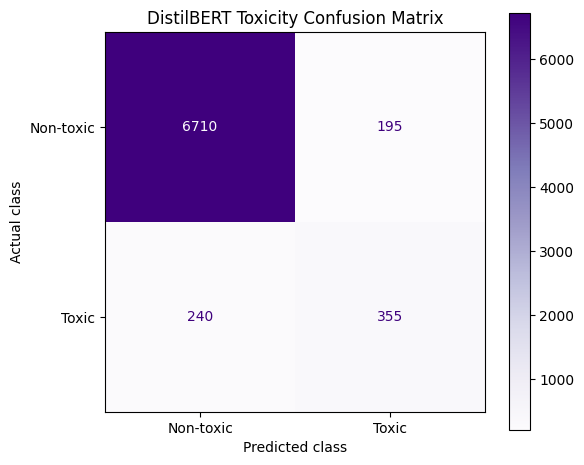

In [23]:
# Cell 21: Generate final predictions and analyse toxic-class performance

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

toxic_prediction_output = toxic_trainer.predict(
    tokenized_toxic["test"]
)

distilbert_toxic_predictions = np.argmax(
    toxic_prediction_output.predictions,
    axis=1
)

true_toxic_labels = toxic_prediction_output.label_ids

print("DistilBERT Toxic Comment Classification Report\n")

print(
    classification_report(
        true_toxic_labels,
        distilbert_toxic_predictions,
        target_names=["Non-toxic", "Toxic"],
        zero_division=0
    )
)

toxic_cm = confusion_matrix(
    true_toxic_labels,
    distilbert_toxic_predictions
)

fig, ax = plt.subplots(figsize=(6, 5))

ConfusionMatrixDisplay(
    confusion_matrix=toxic_cm,
    display_labels=["Non-toxic", "Toxic"]
).plot(
    cmap="Purples",
    values_format="d",
    ax=ax
)

ax.set_title("DistilBERT Toxicity Confusion Matrix")
ax.set_xlabel("Predicted class")
ax.set_ylabel("Actual class")

plt.tight_layout()
plt.show()

In [24]:
# Cell 22: Create the final toxicity model comparison table

toxicity_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "DistilBERT"
    ],
    "Accuracy": [
        lr_accuracy,
        toxic_test_results["eval_accuracy"]
    ],
    "Precision": [
        lr_precision,
        toxic_test_results["eval_precision"]
    ],
    "Recall": [
        lr_recall,
        toxic_test_results["eval_recall"]
    ],
    "F1-score": [
        lr_f1,
        toxic_test_results["eval_f1"]
    ]
})

toxicity_comparison = toxicity_comparison.round(4)

print("Final Toxicity Model Comparison")
display(toxicity_comparison)

Final Toxicity Model Comparison


,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.8917,0.9192,0.8917,0.9028
1,DistilBERT,0.9420,0.9401,0.9420,0.9410
